In [ ]:
!pip install xgboost shap imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Kaggle Credit Card Fraud dataset (public, 284k transactions)
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


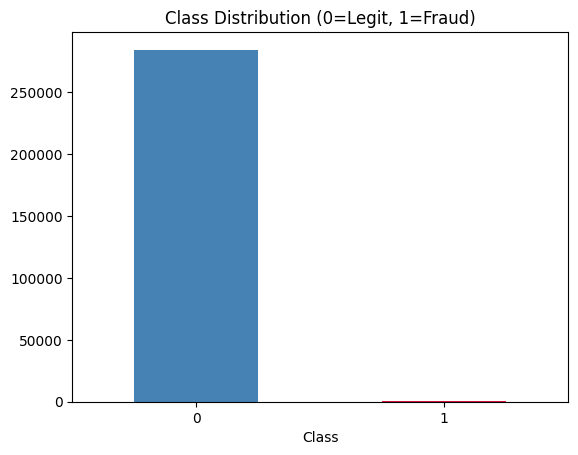

In [ ]:
# Class imbalance — this is the core problem
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")

# Plot
df['Class'].value_counts().plot(kind='bar', color=['steelblue','crimson'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xticks(rotation=0)
plt.show()

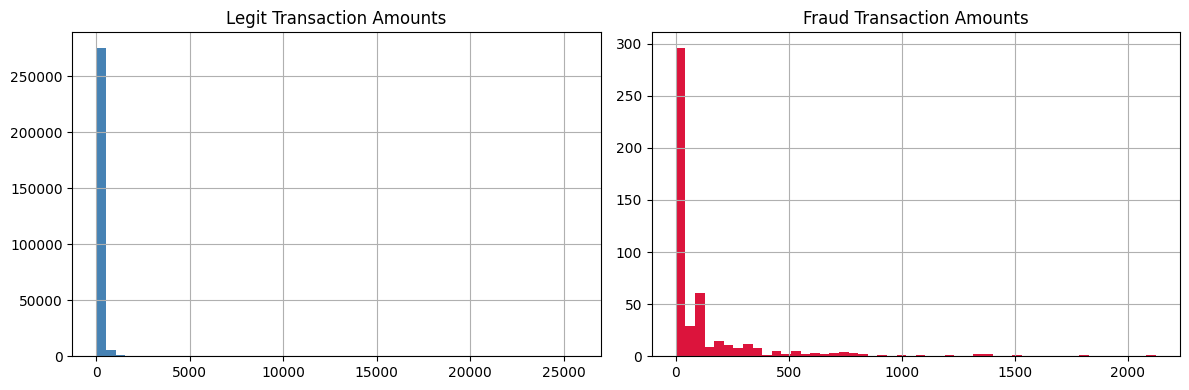

In [ ]:
# Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['Class']==0]['Amount'].hist(ax=axes[0], bins=50, color='steelblue')
axes[0].set_title('Legit Transaction Amounts')
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, color='crimson')
axes[1].set_title('Fraud Transaction Amounts')
plt.tight_layout()
plt.show()

In [ ]:
# Keep a raw copy BEFORE scaling so we can save a proper sample CSV later
df_raw = df.copy()

# FIX 1: Use TWO separate scalers (not one re-fit on both columns).
# Previously: scaler was re-fit on Time, overwriting Amount stats → scaler.pkl was broken.
amount_scaler = StandardScaler()
time_scaler   = StandardScaler()
df['Amount_scaled'] = amount_scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = time_scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split BEFORE any resampling (stratified to preserve 0.17% fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# FIX 2: Remove SMOTE. SMOTE created a fake 50/50 balance which destroys
# probability calibration — on real data (0.17% fraud) the model then outputs
# near-zero probabilities for fraud transactions, making any threshold useless.
# Instead, let XGBoost handle imbalance natively via scale_pos_weight.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}  (legit / fraud ratio in training set)")
print(f"Train — Fraud: {(y_train==1).sum():,}  Legit: {(y_train==0).sum():,}")
print(f"Test  — Fraud: {(y_test==1).sum():,}   Legit: {(y_test==0).sum():,}")


In [ ]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # FIX 3: replaces SMOTE for imbalance handling
    eval_metric='auc',
    random_state=42
    # FIX 4: removed use_label_encoder=False — deprecated & removed in XGBoost >= 1.6
)

# Train on the REAL (unsampled) training data
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)


Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9769
Avg Precision Score: 0.8619


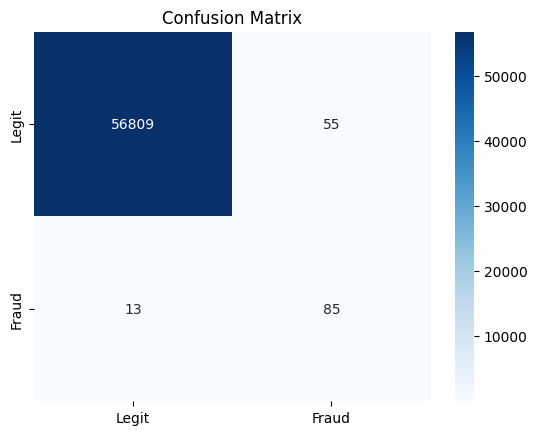

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Precision Score: {average_precision_score(y_test, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Use a sample for speed (SHAP on full test set is slow in Colab)
explainer = shap.TreeExplainer(model)
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed:", shap_values.shape)

SHAP values computed: (1000, 30)


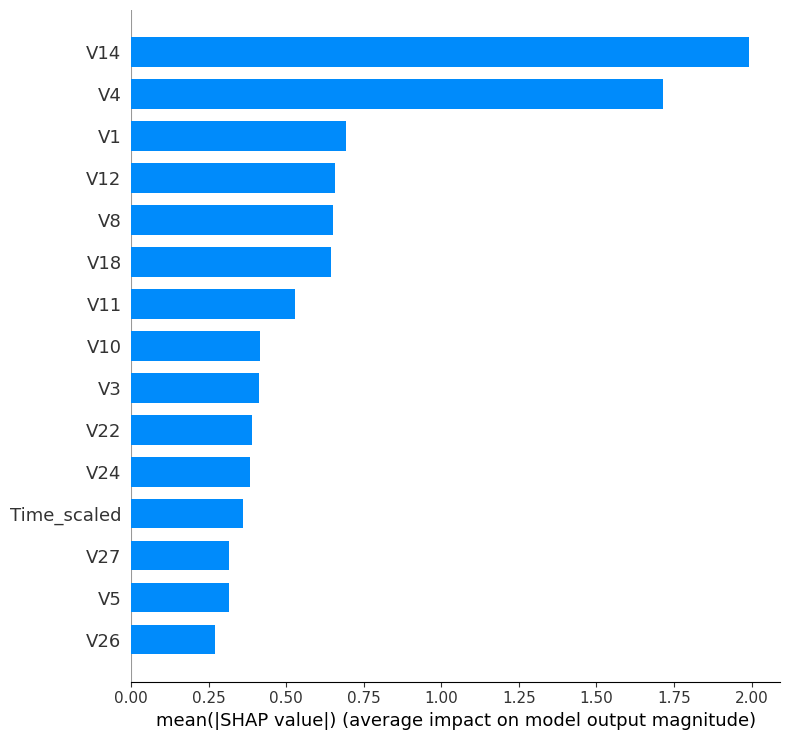

In [ ]:
# Which features matter most globally?
shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
                  max_display=15, show=True)

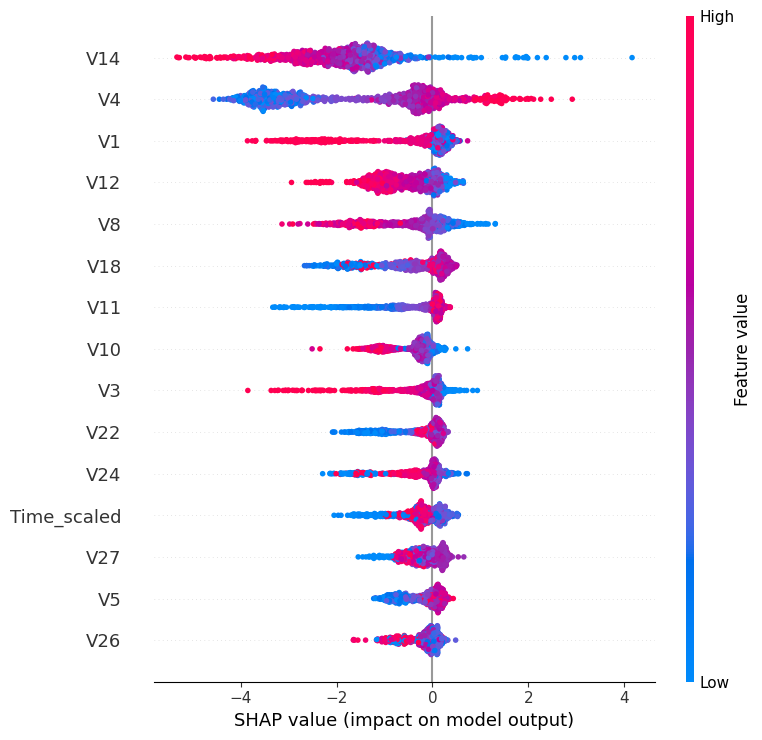

In [ ]:
# Shows direction of impact too — red = high value, blue = low value
shap.summary_plot(shap_values, X_test_sample, max_display=15)

First fraud at position: 840


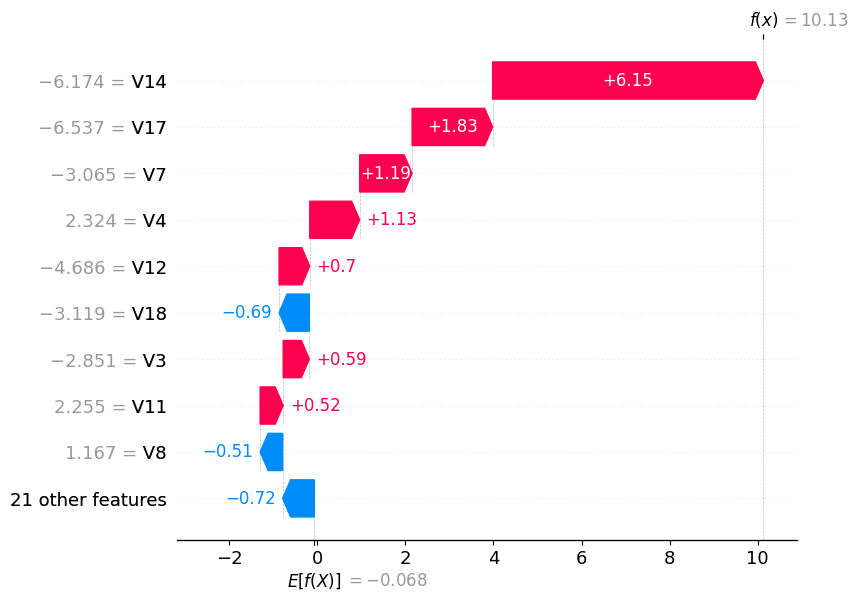

In [ ]:
# Get fraud indices and reset X_test for positional access
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Find first fraud position
fraud_pos = y_test_reset[y_test_reset == 1].index[0]
print(f"First fraud at position: {fraud_pos}")

# Compute SHAP on a window around it
start = max(0, fraud_pos - 10)
end = fraud_pos + 1
shap_window = explainer.shap_values(X_test_reset.iloc[start:end])

local_idx = end - start - 1  # last row = our fraud case

shap.plots.waterfall(
    shap.Explanation(
        values=shap_window[local_idx],
        base_values=explainer.expected_value,
        data=X_test_reset.iloc[fraud_pos].values,
        feature_names=X_test.columns.tolist()
    )
)

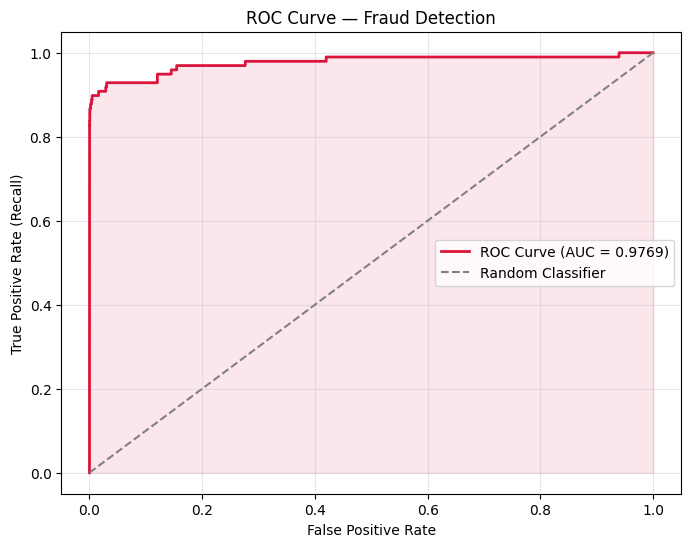

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2,
         label=f'ROC Curve (AUC = 0.9769)')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='crimson')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Fraud Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

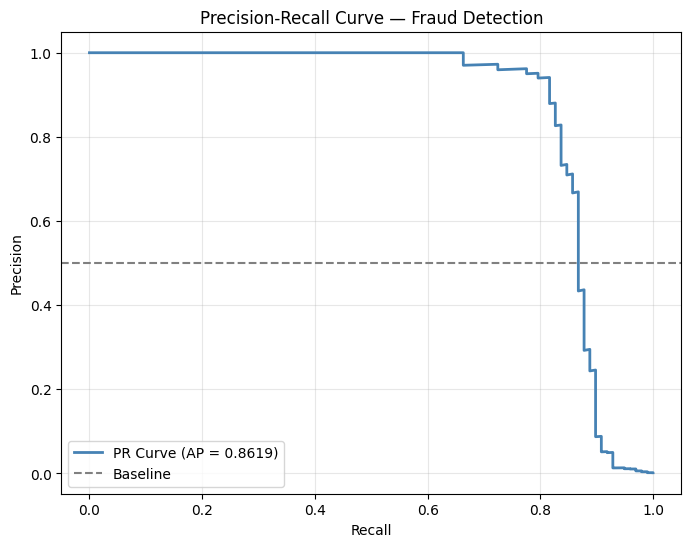

In [ ]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='steelblue', lw=2,
         label=f'PR Curve (AP = 0.8619)')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Fraud Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import f1_score

f1_scores = []
# FIX 5: Previously range stopped at 0.90, so 0.89 was always the last value
# and looked like the "best" by coincidence — it was just the boundary, not the optimum.
threshold_range = np.arange(0.01, 1.00, 0.01)   # full range

for t in threshold_range:
    preds = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, preds)
    f1_scores.append(f1)

best_threshold = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(threshold_range, f1_scores, color='purple', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score (Fraud)')
plt.title('F1 Score vs Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")


=== Results with Tuned Threshold ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



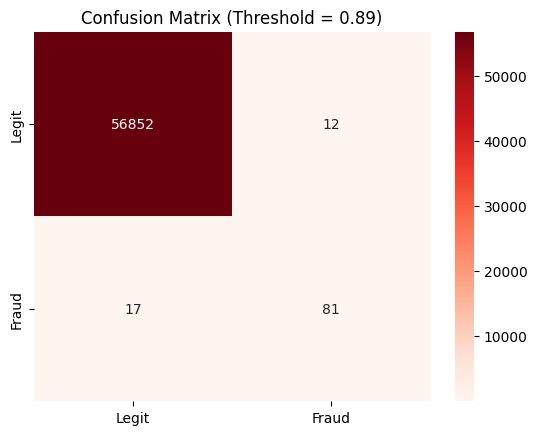

In [ ]:
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("=== Results with Tuned Threshold ===")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Legit', 'Fraud']))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.2f})')
plt.show()

In [ ]:
import pickle, json

# Save model
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# FIX 6: Save BOTH scalers in a dict (was: saving one broken scaler that only knew Time stats).
with open('scaler.pkl', 'wb') as f:
    pickle.dump({'amount_scaler': amount_scaler, 'time_scaler': time_scaler}, f)

# FIX 7: Persist the optimal threshold so the Streamlit app loads it automatically
# instead of hardcoding a wrong value.
with open('model_config.json', 'w') as f:
    json.dump({'best_threshold': float(best_threshold)}, f, indent=2)

# FIX 8: Save sample CSV with RAW Amount + Time columns (not pre-scaled).
# Previously X_test already had Amount/Time dropped, so the saved CSV had
# Amount_scaled/Time_scaled — contradicting the app's expected input format.
test_raw = df_raw.loc[X_test.index].copy()          # raw columns (Amount, Time, V1-V28, Class)
test_raw.head(200).to_csv('sample_transactions.csv', index=False)

# Also regenerate the fraud demo file from the raw data
fraud_rows = test_raw[test_raw['Class'] == 1]
legit_rows = test_raw[test_raw['Class'] == 0].head(21)
demo = pd.concat([legit_rows, fraud_rows]).reset_index(drop=True)
demo.to_csv('sample_transactions_with_fraud.csv', index=False)

print("Saved: fraud_model.pkl, scaler.pkl, model_config.json")
print(f"  Threshold saved: {best_threshold:.2f}")
print(f"  sample_transactions.csv — shape: {test_raw.head(200).shape}, columns: {test_raw.columns.tolist()}")
print(f"  sample_transactions_with_fraud.csv — {len(demo)} rows ({len(fraud_rows)} fraud, {len(legit_rows)} legit)")
